In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
## Checking for Missing Values

In [13]:
df.shape

(9994, 21)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

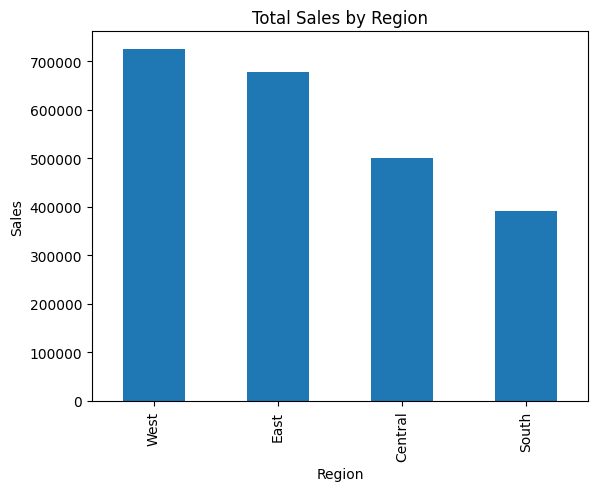

In [12]:
region_sales.plot(kind='bar')
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.show()

In [14]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [16]:
df.groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [17]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

In [18]:
df.groupby('Sub-Category')[['Profit', 'Discount']].mean().sort_values(by='Profit')

,Profit,Discount
Sub-Category,,
Tables,-55.565771,0.261285
Bookcases,-15.230509,0.211140
Supplies,-6.258418,0.076842
Fasteners,4.375660,0.082028
Art,8.200737,0.074874
Furnishings,13.645918,0.138349
Labels,15.236962,0.068681
Binders,19.843574,0.372292
Paper,24.856620,0.074891


In [19]:
pd.pivot_table(
    df,
    values='Profit',
    index='Sub-Category',
    columns='Region',
    aggfunc='sum'
)

Region,Central,East,South,West
Sub-Category,,,,
Accessories,7251.6306,11195.8644,7004.5424,16484.5983
Appliances,-2638.6175,8391.4134,4123.9396,8261.2699
Art,1195.1591,1899.9443,1058.5866,2374.0970
Binders,-1043.6369,11267.9346,3900.6640,16096.8016
Bookcases,-1997.9043,-1167.6318,1339.4918,-1646.5117
Chairs,6592.7221,9357.7706,6612.0893,4027.5843
Copiers,15608.8413,17022.8418,3658.9067,19327.2351
Envelopes,1777.5283,1812.4090,1465.4770,1908.7624
Fasteners,236.6186,263.9908,173.7181,275.1907


In [20]:
df.groupby('Sub-Category')[['Profit','Discount']].mean().sort_values(by='Profit')

,Profit,Discount
Sub-Category,,
Tables,-55.565771,0.261285
Bookcases,-15.230509,0.211140
Supplies,-6.258418,0.076842
Fasteners,4.375660,0.082028
Art,8.200737,0.074874
Furnishings,13.645918,0.138349
Labels,15.236962,0.068681
Binders,19.843574,0.372292
Paper,24.856620,0.074891


In [21]:
df[df['Sub-Category'] == 'Tables'].groupby('Region')['Profit'].sum()

Region
Central    -3559.6504
East      -11025.3801
South      -4623.0579
West        1482.6073
Name: Profit, dtype: float64

In [22]:
##The tables sub-category demonstrate the lowest overall profit margib across the categories.
##Further regional analysis revleas that the east region contributes the highestlosseswithin this sub-category. 

In [23]:
df[df['Sub-Category'] == 'Tables'].groupby('Region')[['Sales','Profit','Discount']].mean()

,Sales,Profit,Discount
Region,,,
Central,543.819042,-49.439589,0.262500
East,489.247588,-137.817251,0.373750
South,861.101804,-90.648194,0.222549
West,730.642776,12.781097,0.200000


In [24]:
tables = df[df['Sub-Category'] == 'Tables']

tables.groupby('Region')[['Sales','Profit']].sum().assign(
    Profit_Margin=lambda x: x['Profit']/x['Sales']
)

,Sales,Profit,Profit_Margin
Region,,,
Central,39154.971,-3559.6504,-0.090912
East,39139.807,-11025.3801,-0.281692
South,43916.192,-4623.0579,-0.105270
West,84754.562,1482.6073,0.017493


In [25]:
##Tables have the worst overall profit margin
##Tables are overall loss-making 
##The east region contributes the highest loss
##The east region also has the lowest profit margin for the tables
##East has the highest average discount for the tables

In [26]:
df.groupby('Region')[['Sales','Profit']].sum().assign(
    Profit_Margin=lambda x: x['Profit']/x['Sales']
)

,Sales,Profit,Profit_Margin
Region,,,
Central,501239.8908,39706.3625,0.079216
East,678781.2400,91522.7800,0.134834
South,391721.9050,46749.4303,0.119343
West,725457.8245,108418.4489,0.149448


In [27]:
##Tables are loss making 
##East is the worst for tables
##But overall region-wise, Central has the worst profit margin

In [28]:
pd.pivot_table(
    df,
    values='Profit',
    index='Sub-Category',
    columns='Region',
    aggfunc='sum'
)

Region,Central,East,South,West
Sub-Category,,,,
Accessories,7251.6306,11195.8644,7004.5424,16484.5983
Appliances,-2638.6175,8391.4134,4123.9396,8261.2699
Art,1195.1591,1899.9443,1058.5866,2374.0970
Binders,-1043.6369,11267.9346,3900.6640,16096.8016
Bookcases,-1997.9043,-1167.6318,1339.4918,-1646.5117
Chairs,6592.7221,9357.7706,6612.0893,4027.5843
Copiers,15608.8413,17022.8418,3658.9067,19327.2351
Envelopes,1777.5283,1812.4090,1465.4770,1908.7624
Fasteners,236.6186,263.9908,173.7181,275.1907


In [29]:
central = df[df['Region'] == 'Central']

central.groupby('Sub-Category')[['Sales','Profit']].sum().assign(
    Profit_Margin=lambda x: x['Profit']/x['Sales']
).sort_values(by='Profit_Margin')

,Sales,Profit,Profit_Margin
Sub-Category,,,
Furnishings,15254.3700,-3906.2168,-0.256072
Appliances,23582.0330,-2638.6175,-0.111891
Tables,39154.9710,-3559.6504,-0.090912
Bookcases,24157.1768,-1997.9043,-0.082704
Supplies,9467.3720,-661.8881,-0.069913
Machines,26797.3840,-1486.0666,-0.055456
Binders,56923.2820,-1043.6369,-0.018334
Storage,45930.1120,1969.8365,0.042888
Chairs,85230.6460,6592.7221,0.077352


In [ ]:
## Final Business Insights

##1. The Tables sub-category shows the lowest overall profit margin and is loss-making.
##2. The East region contributes the highest losses for Tables.
##3. The Central region has the lowest overall profit margin among all regions.
##4. Within Central, Furnishings has the weakest profitability performance.
##5. Discount strategy and regional pricing inefficiencies may be contributing to margin pressure.